In [94]:
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller,kpss 
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

### Load Data from Kaggle

In [95]:
DATA_PATH=Path('data/yahoo_stock.csv')
df=pd.read_csv(DATA_PATH)
df.head()

,Date,High,Low,Open,Close,Volume,Adj Close
0,2015-11-23,2095.610107,2081.389893,2089.409912,2086.590088,3.587980e+09,2086.590088
1,2015-11-24,2094.120117,2070.290039,2084.419922,2089.139893,3.884930e+09,2089.139893
2,2015-11-25,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
3,2015-11-26,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
4,2015-11-27,2093.290039,2084.129883,2088.820068,2090.110107,1.466840e+09,2090.110107


### Basic EDA (info, shape, etc )

In [96]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1825 non-null   str    
 1   High       1825 non-null   float64
 2   Low        1825 non-null   float64
 3   Open       1825 non-null   float64
 4   Close      1825 non-null   float64
 5   Volume     1825 non-null   float64
 6   Adj Close  1825 non-null   float64
dtypes: float64(6), str(1)
memory usage: 99.9 KB


In [97]:
df.shape

(1825, 7)

In [98]:
df.isnull().sum()

Date         0
High         0
Low          0
Open         0
Close        0
Volume       0
Adj Close    0
dtype: int64

In [99]:
df.describe()

,High,Low,Open,Close,Volume,Adj Close
count,1825.000000,1825.000000,1825.000000,1825.000000,1.825000e+03,1825.000000
mean,2660.718673,2632.817580,2647.704751,2647.856284,3.869627e+09,2647.856284
std,409.680853,404.310068,407.169994,407.301177,1.087593e+09,407.301177
min,1847.000000,1810.099976,1833.400024,1829.079956,1.296540e+09,1829.079956
25%,2348.350098,2322.250000,2341.979980,2328.949951,3.257950e+09,2328.949951
50%,2696.250000,2667.840088,2685.489990,2683.340088,3.609740e+09,2683.340088
75%,2930.790039,2900.709961,2913.860107,2917.520020,4.142850e+09,2917.520020
max,3645.989990,3600.159912,3612.090088,3626.909912,9.044690e+09,3626.909912


In [100]:
df['Date']=pd.to_datetime(df['Date'], errors='coerce')

In [101]:
df = df.sort_values('Date').set_index('Date')

In [102]:
df.head()

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2015-11-23,2095.610107,2081.389893,2089.409912,2086.590088,3.587980e+09,2086.590088
2015-11-24,2094.120117,2070.290039,2084.419922,2089.139893,3.884930e+09,2089.139893
2015-11-25,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
2015-11-26,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
2015-11-27,2093.290039,2084.129883,2088.820068,2090.110107,1.466840e+09,2090.110107


### Check duplicated 

In [103]:
df.index.duplicated().sum()

np.int64(0)

### Check Monotonicity (chronological order), Date distribution and Date range

In [104]:
gaps=df.index.to_series().diff().value_counts().sort_index()
print(gaps.head(10))

Date
1 days    1824
Name: count, dtype: int64


In [105]:
print("Chronological order?", df.index.is_monotonic_increasing)

Chronological order? True


In [106]:
print(f'Range: {df.index.min()} to {df.index.max()}')
print(f'Number of rows {len(df)}, Calendar days: {(df.index.max()-df.index.min()).days}')

Range: 2015-11-23 00:00:00 to 2020-11-20 00:00:00
Number of rows 1825, Calendar days: 1824


<Axes: >

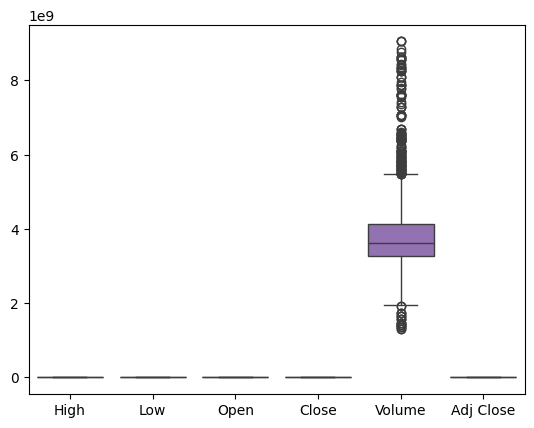

In [107]:
sns.boxplot(data=df)

<Axes: >

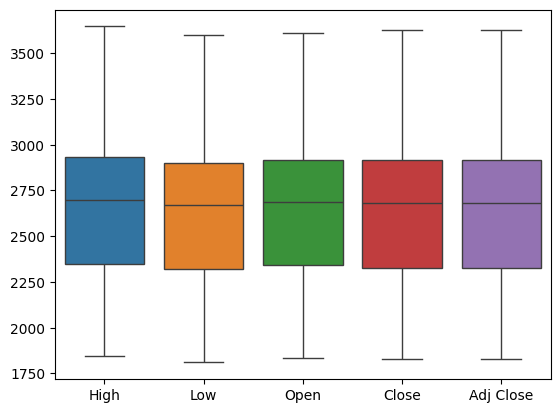

In [108]:
sns.boxplot(data=df[['High','Low','Open','Close','Adj Close']])

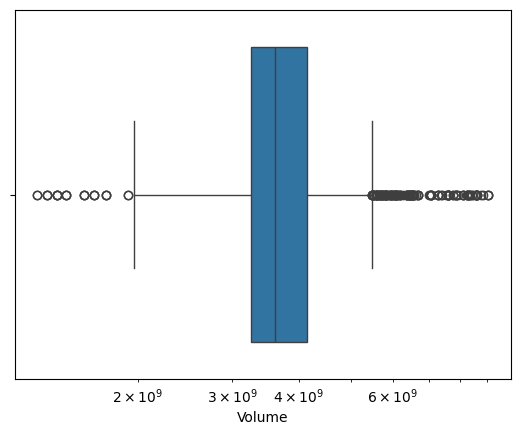

In [109]:
sns.boxplot(x=df['Volume'])
plt.xscale('log')

In [110]:
Q1=df['Volume'].quantile(0.25)
Q3=df['Volume'].quantile(0.75)
IQR=Q3-Q1
IQR

np.float64(884900000.0)

In [111]:
upper = Q3 + 1.5*IQR
outliers = df[df['Volume'] > upper]
print(f"IQR-outlier: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
outliers.head()

IQR-outlier: 139 (7.6%)


,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2015-12-18,2040.810059,2005.329956,2040.810059,2005.550049,6.683070e+09,2005.550049
2015-12-19,2040.810059,2005.329956,2040.810059,2005.550049,6.683070e+09,2005.550049
2015-12-20,2040.810059,2005.329956,2040.810059,2005.550049,6.683070e+09,2005.550049
2016-01-20,1876.180054,1812.290039,1876.180054,1859.329956,6.416070e+09,1859.329956
2016-01-29,1940.239990,1894.000000,1894.000000,1940.239990,5.497570e+09,1940.239990


In [112]:
Q99=df['Volume'].quantile(0.99)
Q99

np.float64(8279190000.0)

In [113]:
outliers = df[df['Volume'] > Q99]
print(f"IQR-outlier: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
outliers.head()

IQR-outlier: 19 (1.0%)


,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2020-02-28,2959.719971,2855.840088,2916.899902,2954.219971,8.563850e+09,2954.219971
2020-02-29,2959.719971,2855.840088,2916.899902,2954.219971,8.563850e+09,2954.219971
2020-03-01,2959.719971,2855.840088,2916.899902,2954.219971,8.563850e+09,2954.219971
2020-03-09,2863.889893,2734.429932,2863.889893,2746.560059,8.423050e+09,2746.560059
2020-03-12,2660.949951,2478.860107,2630.860107,2480.639893,8.829380e+09,2480.639893


<Axes: title={'center': 'Volume'}, xlabel='Date'>

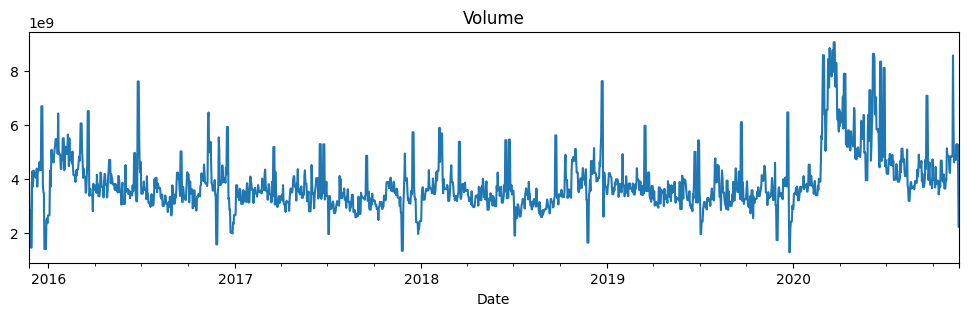

In [114]:
df['Volume'].plot(figsize=(12,3), title='Volume')

<Axes: >

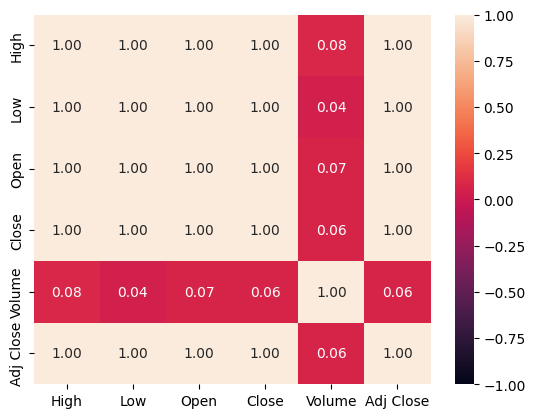

In [115]:
feature=df.select_dtypes(include='number')
sns.heatmap(data=feature.corr(),vmax=1,vmin=-1,fmt='.2f',annot=True)

### Rolling means

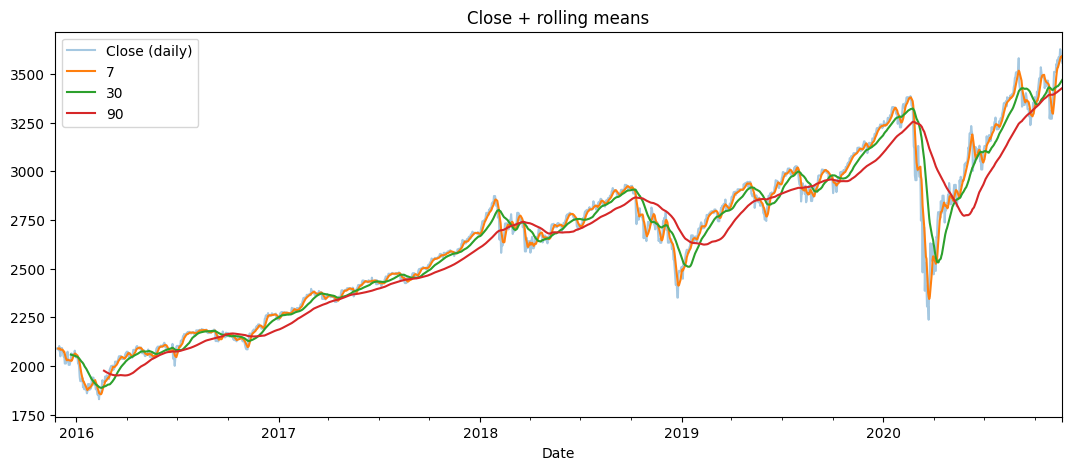

In [116]:
fig ,ax = plt.subplots(figsize=(13,5))
df['Close'].plot(ax=ax,alpha=0.4,label='Close (daily)')
df['Close'].rolling(7).mean().plot(ax=ax, label='7')
df['Close'].rolling(30).mean().plot(ax=ax, label='30')
df['Close'].rolling(90).mean().plot(ax=ax, label='90')
ax.legend()
ax.set_title('Close + rolling means')
plt.show()

### Returns

In [117]:
df['return']=df['Close'].pct_change()
df['return']

Date
2015-11-23         NaN
2015-11-24    0.001222
2015-11-25   -0.000129
2015-11-26    0.000000
2015-11-27    0.000594
                ...   
2020-11-16    0.011648
2020-11-17   -0.004792
2020-11-18   -0.011564
2020-11-19    0.003946
2020-11-20   -0.006793
Name: return, Length: 1825, dtype: float64

In [118]:
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
df['log_return']

Date
2015-11-23         NaN
2015-11-24    0.001221
2015-11-25   -0.000129
2015-11-26    0.000000
2015-11-27    0.000593
                ...   
2020-11-16    0.011581
2020-11-17   -0.004803
2020-11-18   -0.011631
2020-11-19    0.003939
2020-11-20   -0.006816
Name: log_return, Length: 1825, dtype: float64

Text(0.5, 1.0, 'Return distribution')

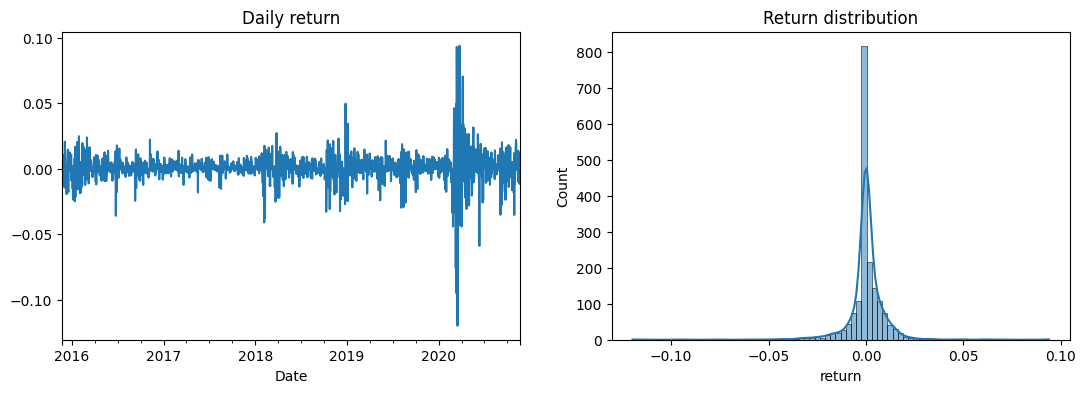

In [119]:
fig,axes= plt.subplots(1,2,figsize=(13,4))
df['return'].plot(ax=axes[0],title='Daily return')
sns.histplot(df['return'].dropna(),bins=80,kde=True,ax=axes[1])
axes[1].set_title('Return distribution')

In [120]:
print(df[['return','log_return']].describe())
print("Skewness:", df['return'].skew(), "Kurtosis:", df['return'].kurt())

            return   log_return
count  1824.000000  1824.000000
mean      0.000344     0.000293
std       0.010119     0.010173
min      -0.119841    -0.127652
25%      -0.001054    -0.001054
50%       0.000000     0.000000
75%       0.002848     0.002843
max       0.093828     0.089683
Skewness: -0.807340208846228 Kurtosis: 30.238550838872342


### ADF + KPSS

In [121]:
s=df['Close'].dropna()
adf=adfuller(s,autolag='AIC')
kpss_stat,kpss_p,*_ = kpss(s,regression='c',nlags='auto')
print(f"ADF  stat={adf[0]:.3f}  p={adf[1]:.4f}  → {'stationary' if adf[1]<0.05 else 'NOT stationary'}")
print(f"KPSS stat={kpss_stat:.3f}  p={kpss_p:.4f}  → {'NOT stationary' if kpss_p<0.05 else 'stationary'}")

ADF  stat=-0.870  p=0.7976  → NOT stationary
KPSS stat=5.859  p=0.0100  → NOT stationary


C:\Users\andra\AppData\Local\Temp\ipykernel_23240\3775521374.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat,kpss_p,*_ = kpss(s,regression='c',nlags='auto')


In [122]:
s=df['Close'].diff().dropna()
adf=adfuller(s,autolag='AIC')
kpss_stat,kpss_p,*_ = kpss(s,regression='c',nlags='auto')
print(f"ADF  stat={adf[0]:.3f}  p={adf[1]:.4f}  → {'stationary' if adf[1]<0.05 else 'NOT stationary'}")
print(f"KPSS stat={kpss_stat:.3f}  p={kpss_p:.4f}  → {'NOT stationary' if kpss_p<0.05 else 'stationary'}")

ADF  stat=-8.522  p=0.0000  → stationary
KPSS stat=0.044  p=0.1000  → stationary


C:\Users\andra\AppData\Local\Temp\ipykernel_23240\3352763759.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat,kpss_p,*_ = kpss(s,regression='c',nlags='auto')


In [123]:
s=df['return'].dropna()
adf=adfuller(s,autolag='AIC')
kpss_stat,kpss_p,*_ = kpss(s,regression='c',nlags='auto')
print(f"ADF  stat={adf[0]:.3f}  p={adf[1]:.4f}  → {'stationary' if adf[1]<0.05 else 'NOT stationary'}")
print(f"KPSS stat={kpss_stat:.3f}  p={kpss_p:.4f}  → {'NOT stationary' if kpss_p<0.05 else 'stationary'}")

ADF  stat=-8.557  p=0.0000  → stationary
KPSS stat=0.042  p=0.1000  → stationary


C:\Users\andra\AppData\Local\Temp\ipykernel_23240\2769330614.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat,kpss_p,*_ = kpss(s,regression='c',nlags='auto')


### Seasonal decomposition

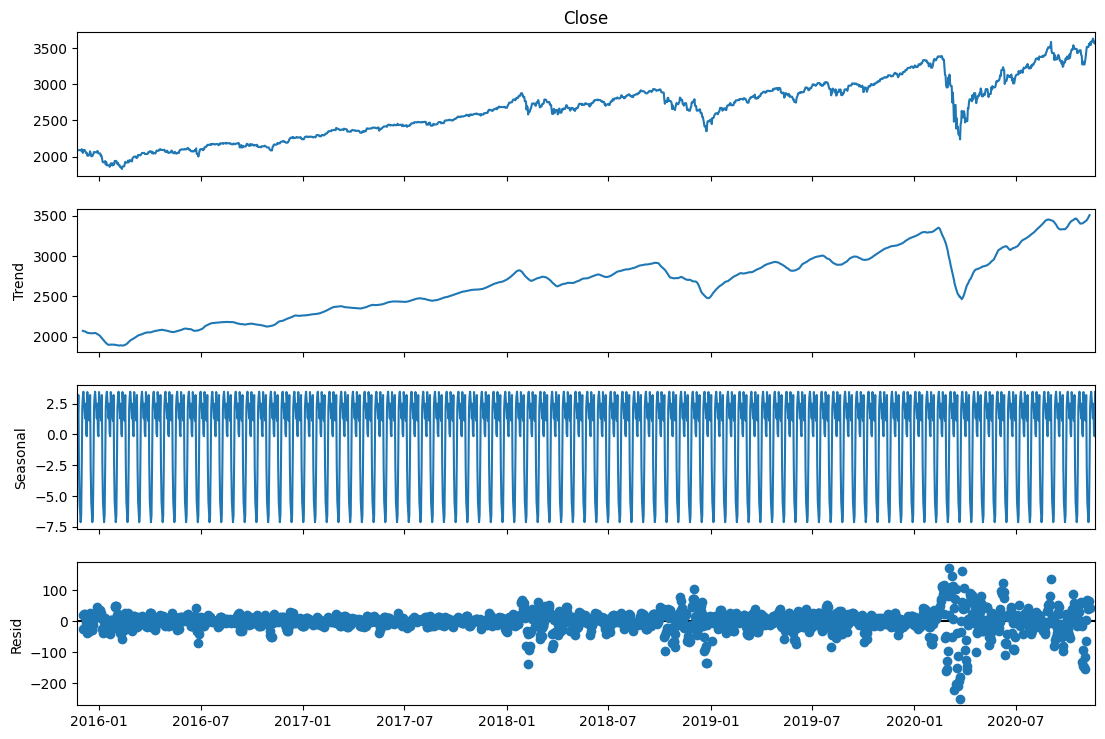

In [124]:
result=seasonal_decompose(df['Close'].dropna(),model='additive',period=21)
result.plot()
plt.gcf().set_size_inches(12,8)
plt.show()

### ACF and PACF

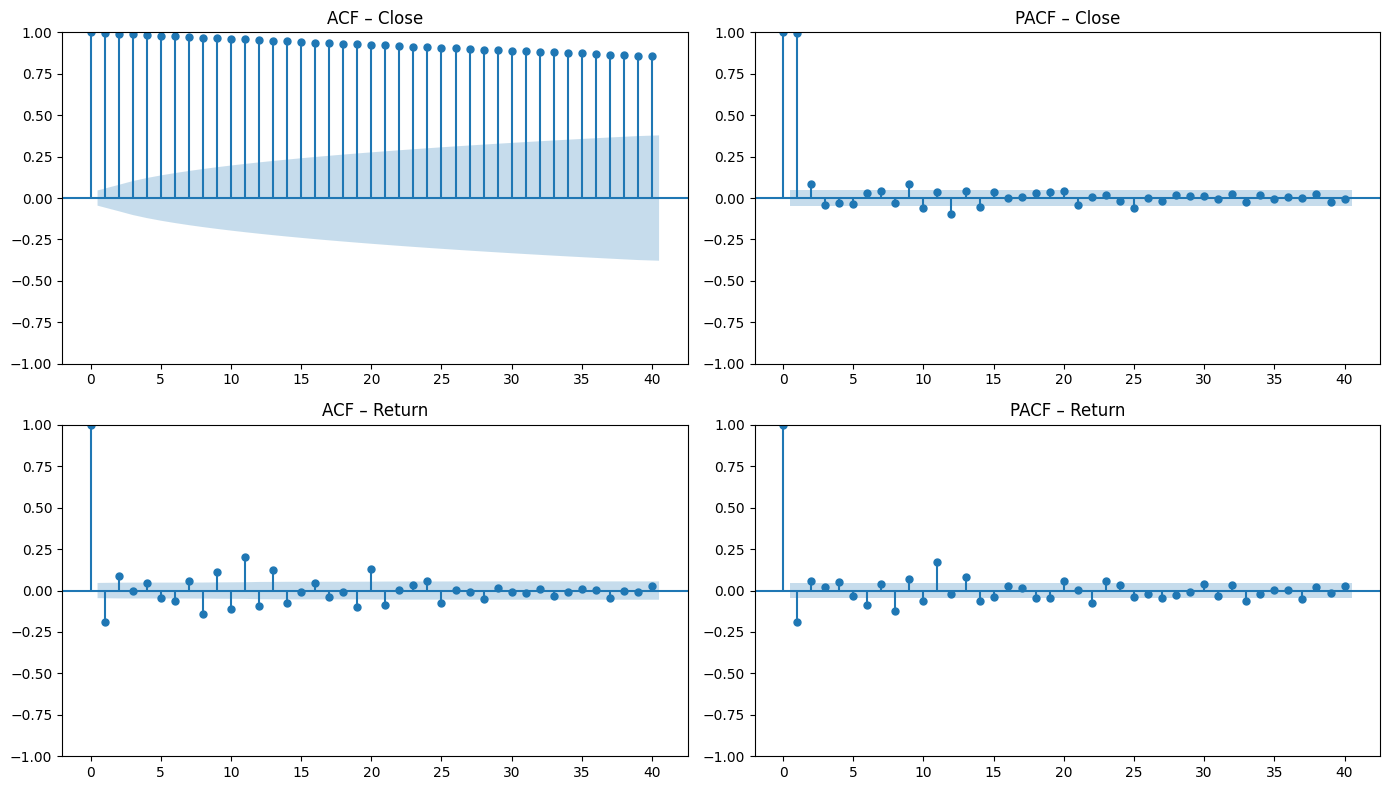

In [125]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_acf(df['Close'].dropna(),  lags=40, ax=axes[0,0]); axes[0,0].set_title('ACF – Close')
plot_pacf(df['Close'].dropna(), lags=40, ax=axes[0,1]); axes[0,1].set_title('PACF – Close')
plot_acf(df['return'].dropna(),  lags=40, ax=axes[1,0]); axes[1,0].set_title('ACF – Return')
plot_pacf(df['return'].dropna(), lags=40, ax=axes[1,1]); axes[1,1].set_title('PACF – Return')
plt.tight_layout()
plt.show()